# Module 3 - Appendiceal Cancer: Adverse Reactions

**Prerequisite:** Run `01_appendiceal_explore.ipynb` first to create the `appendiceal_reports` table.

In [48]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

In [49]:
##Open appendiceal cohort table created in 01_appendiceal_explore.ipynb and sort by number of reactions reported for each symptom.
# Query with percentage of drug reports instead of raw counts
# Subquery calculates total reports per drug, then we divide each reaction count by that total


appendiceal_cohort_reactions_pct = pd.read_sql_query("""
    SELECT 
        ac.drugname,
        ac.reaction,
        COUNT(*) AS reports,
        ROUND(100.0 * COUNT(*) / drug_totals.total, 1) AS pct_of_drug_reports
    FROM appendiceal_cohort ac
    JOIN (
        SELECT drugname, COUNT(*) AS total
        FROM appendiceal_cohort
        GROUP BY drugname
        HAVING COUNT(*) >= 20
    ) drug_totals ON ac.drugname = drug_totals.drugname
    GROUP BY ac.drugname, ac.reaction
    HAVING pct_of_drug_reports > 4
    ORDER BY ac.drugname, pct_of_drug_reports DESC
""", conn)



appendiceal_cohort_reactions_pct.head(20)

,drugname,reaction,reports,pct_of_drug_reports
0,BEVACIZUMAB,Deep vein thrombosis,6,10.2
1,BEVACIZUMAB,Streptococcal infection,4,6.8
2,BEVACIZUMAB,Off label use,4,6.8
3,BEVACIZUMAB,Fusobacterium infection,4,6.8
4,BEVACIZUMAB,Brain abscess,4,6.8
5,BEVACIZUMAB,Pulmonary embolism,3,5.1
6,CAPECITABINE,Diarrhoea,12,8.6
7,CAPECITABINE,Gastrointestinal injury,10,7.1
8,CAPECITABINE,Pyrexia,8,5.7
9,CAPECITABINE,Abdominal pain,8,5.7


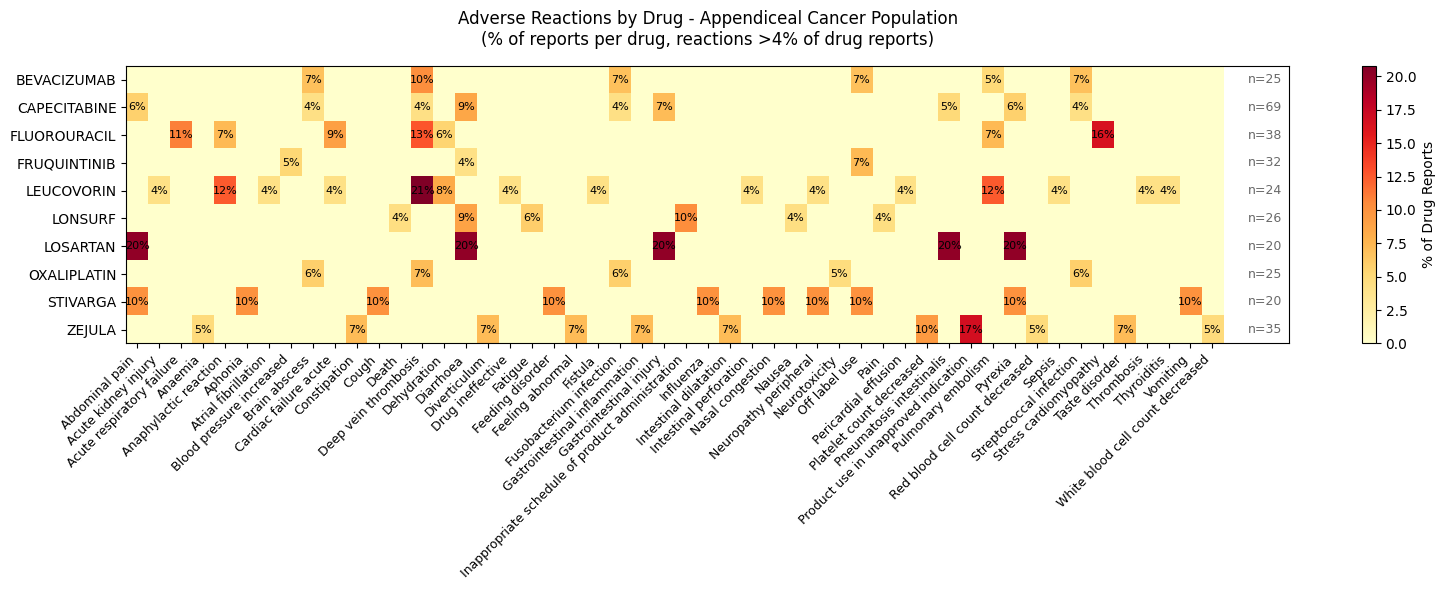

In [53]:
# Heatmap: % of each drug's reports containing a given reaction
# Filters: drugs with >=20 total reports, reactions >4% of drug reports
# Color intensity = % of drug reports; n= shows total reaction rows per dru


import matplotlib.pyplot as plt
import numpy as np

# Get total reports per drug for n= labels
drug_totals = appendiceal_cohort_reactions_pct.groupby('drugname')['reports'].sum()

pivot = appendiceal_cohort_reactions_pct.pivot_table(
    index='drugname',
    columns='reaction',
    values='pct_of_drug_reports',
    fill_value=0
)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(pivot.index, fontsize=10)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=8, color='black')

for i, drug in enumerate(pivot.index):
    total = drug_totals.get(drug, 0)
    ax.text(len(pivot.columns) + 0.6, i, f'n={int(total)}',
            va='center', ha='left', fontsize=9, color='dimgray')

ax.set_xlim(-0.5, len(pivot.columns) + 2.5)
plt.colorbar(im, ax=ax, label='% of Drug Reports')
plt.title('Adverse Reactions by Drug - Appendiceal Cancer Population\n(% of reports per drug, reactions >4% of drug reports)',
          fontsize=12, pad=15)
plt.tight_layout()
plt.show()



### Interpretation

The heatmap shows the percentage of each drug's reports containing a given reaction,
filtered to drugs with ≥20 total reports and reactions exceeding 4% of drug reports.
Given the small cohort size (~339 reports), findings should be interpreted directionally
rather than as statistically validated conclusions.

**Key observations:**

**Fruquintinib - Off label use (highest signal)**
Fruquintinib received FDA approval in 2023 for refractory metastatic colorectal cancer.
Its dominance here reflects limited approved options for rare peritoneal malignancies and
clinician willingness to use newer agents off-label in heavily pre-treated patients.

**Deep vein thrombosis - cross-drug pattern**
DVT appears across capecitabine, fluorouracil, oxaliplatin, leucovorin, and bevacizumab, which is
the broadest cross-drug signal in this dataset. Reflects cancer-associated thrombosis, a
known complication of both peritoneal malignancy and chemotherapy, rather than a
drug-specific toxicity.

**Fluorouracil - Stress cardiomyopathy**
Consistent with the cardiotoxicity signal identified in Module 1 (ROR=15.0). Replication
in this indication-filtered population strengthens its clinical relevance.

**Capecitabine - Diarrhoea and GI injury**
Expected fluoropyrimidine toxicity. Capecitabine is oral 5-FU and shares the same GI
toxicity profile documented in Module 1.

**Brain abscess - Capecitabine and Oxaliplatin**
Unusual signal. May reflect immunosuppression from chemotherapy or CRS/HIPEC surgery
creating vulnerability to opportunistic CNS infection. Interpret cautiously given small n.

> **Data sparsity caveat:** ~339 total reports. All findings are hypothesis-generating
> and should be validated in larger datasets before clinical conclusions are drawn.


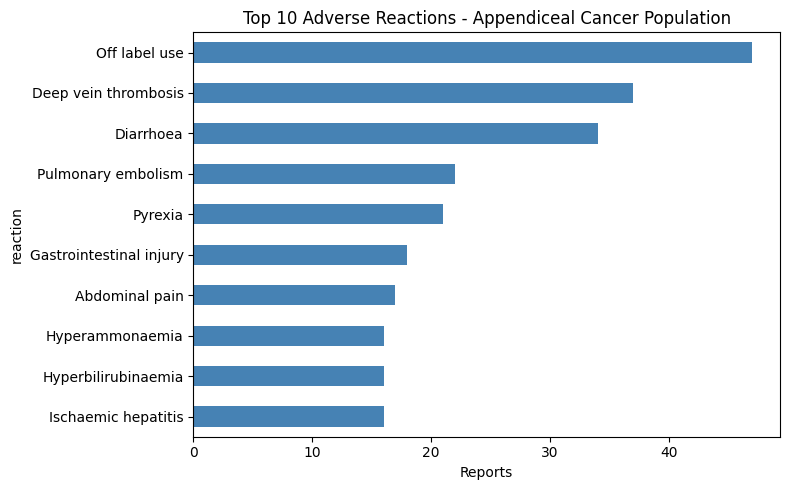

In [54]:
top_reactions = pd.read_sql_query("""
    SELECT reaction, COUNT(*) AS reports
    FROM appendiceal_cohort
    GROUP BY reaction
    ORDER BY reports DESC
    LIMIT 10
""", conn)

top_reactions.sort_values('reports').plot(
    kind='barh', x='reaction', y='reports', legend=False,
    color='steelblue', figsize=(8, 5)
)
plt.xlabel('Reports')
plt.title('Top 10 Adverse Reactions - Appendiceal Cancer Population')
plt.tight_layout()
plt.show()


### Overall Reaction Profile

Across all appendiceal cancer reports, **off label use (n=47)** and **deep vein thrombosis (n=37)**
are the two dominant signals, followed by diarrhoea (n=34).

**Off label use** as the top reaction reflects the limited approved treatment options for appendiceal
cancer, which is a rare malignancy without dedicated FDA-approved regimens. Clinicians routinely adapt
colorectal cancer protocols (FOLFOX, FOLFIRI) and use newer targeted agents (fruquintinib) outside
their approved indications.

**DVT and pulmonary embolism** both appear in the top 10, together representing a strong
thromboembolic signal consistent with the known hypercoagulable state of peritoneal malignancy
patients; particularly those undergoing major cytoreductive surgery.

**Hyperammonaemia and hyperbilirubinaemia** in the lower tier suggest hepatic stress, which may
reflect disease burden (peritoneal/hepatic metastases) or hepatotoxicity from chemotherapy regimens
common in this population.

**Ischaemic hepatitis** Unusual and worth noting. May reflect vascular compromise in the
setting of extensive peritoneal disease or surgical intervention.
